# 02. 비용 관점 탐색

일반 EDA(01)와 분리한 이유가 있다.

**우리 목적 함수는 금액 가중이다.** 따라서 '사기 *건수* 분포'가 아니라
**'사기 *금액* 분포'** 를 봐야 한다. 이 노트북의 결과가 정책 설계(§5)의
직접적 근거가 된다.

핵심 질문 세 가지:

1. 손실이 소수 고액 거래에 집중되어 있는가? → **P4(금액 의존 임계값)의 가치를 예측**
2. 금액 구간별 사기율과 손실 총액의 순위가 다른가?
3. 세그먼트별 사기율 격차가 얼마나 큰가? → 공정성 점검의 사전 작업

In [15]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


from frauddetectionreport import config, data
from frauddetectionreport.config import TARGET, AMOUNT_COL, TIME_COL

train = data.load("train")
amt = train[AMOUNT_COL].to_numpy()
y = train[TARGET].to_numpy().astype(bool)

print(f"전체 {len(train):,}건 / 사기 {y.sum():,}건 ({y.mean():.2%})")
print(f"사기 금액 비중: {amt[y].sum() / amt.sum():.2%}")

Task was destroyed but it is pending!
task: <Task pending name='Task-209' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-210' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\fraudDetectionReport\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\fraudDetectionReport\.venv\Lib\site-packages\pandas\core\internals\managers.py:1132: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  tot_items = sum(len(x.mgr_locs) for x in self.blocks)
Task was destroyed but it is pending!
task: <Task pending name='Task-210' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


전체 590,540건 / 사기 20,663건 (3.50%)
사기 금액 비중: 3.87%


> **주의**: `TransactionAmt` 는 대회 호스트 설명상 USD 거래금액이다. 다만
> chargeback·오차단·검토 비용은 관측되지 않은 가정값이므로 절대 비용 결론은 내리지 않는다.
> 총비용은 P0 대비 절감률과 민감도 분석을 중심으로 보고한다 (기획서 §2.3).

## 1. 금액 분포 — 정상 vs 사기

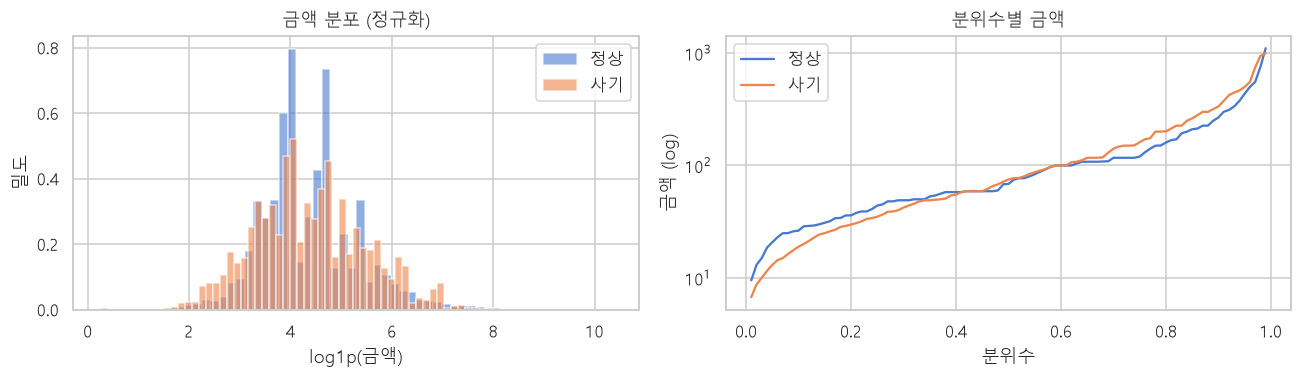

정상 중앙값    68.50   평균   134.51
사기 중앙값    75.00   평균   149.24


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(np.log1p(amt[~y]), bins=60, density=True, alpha=0.6, label="정상")
axes[0].hist(np.log1p(amt[y]), bins=60, density=True, alpha=0.6, label="사기")
axes[0].set_xlabel("log1p(금액)"); axes[0].set_ylabel("밀도"); axes[0].legend()
axes[0].set_title("금액 분포 (정규화)")

q = np.linspace(0.01, 0.99, 99)
axes[1].plot(q, np.quantile(amt[~y], q), label="정상")
axes[1].plot(q, np.quantile(amt[y], q), label="사기")
axes[1].set_yscale("log"); axes[1].set_xlabel("분위수"); axes[1].set_ylabel("금액 (log)")
axes[1].legend(); axes[1].set_title("분위수별 금액")
plt.tight_layout(); plt.show()

print(f"정상 중앙값 {np.median(amt[~y]):8.2f}   평균 {amt[~y].mean():8.2f}")
print(f"사기 중앙값 {np.median(amt[y]):8.2f}   평균 {amt[y].mean():8.2f}")

## 2. 손실 집중도 ← **가장 중요한 분석**

사기 손실의 몇 %가 상위 몇 %의 거래에서 발생하는가.

- **집중되어 있다면**: 고액 거래를 정밀하게 잡는 것이 총비용을 좌우한다
  → P4(금액 의존 임계값)가 P3 대비 큰 개선을 보일 것
- **고르게 퍼져 있다면**: 금액 차등의 이득이 작을 것
  → P4 ≈ P3 이라는 결과가 나와도 놀랄 일이 아니다

이 예측을 06에서 실제 결과와 대조한다.

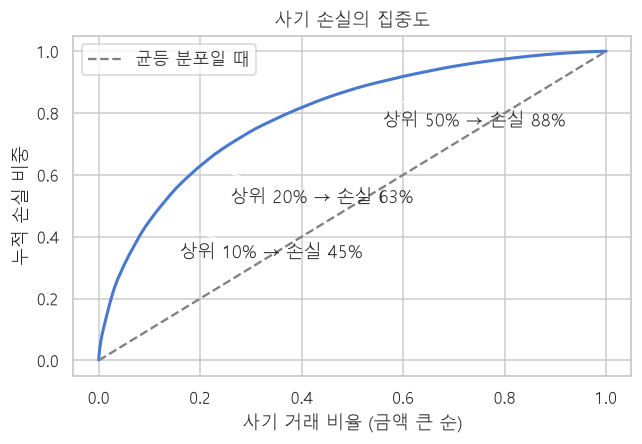

In [17]:
loss = np.sort(amt[y])[::-1]          # 사기 손실 내림차순
cum = np.cumsum(loss) / loss.sum()
frac = np.arange(1, len(loss) + 1) / len(loss)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(frac, cum, lw=2)
ax.plot([0, 1], [0, 1], "--", c="gray", label="균등 분포일 때")
for f in (0.1, 0.2, 0.5):
    c = cum[int(f * len(loss)) - 1]
    ax.annotate(f"상위 {f:.0%} → 손실 {c:.0%}", xy=(f, c),
                xytext=(f + 0.06, c - 0.12), arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("사기 거래 비율 (금액 큰 순)"); ax.set_ylabel("누적 손실 비중")
ax.set_title("사기 손실의 집중도"); ax.legend()
plt.tight_layout(); plt.show()

## 3. 금액 구간별 사기율 vs 손실 총액

**두 지표의 순위가 다를 것이다.** 소액 구간은 사기율이 높아도 손실 총액이 작고,
고액 구간은 사기율이 낮아도 손실이 클 수 있다.

건수 기준으로만 보면 정책이 엉뚱한 구간에 집중하게 된다 —
이것이 목적 함수를 명시해야 하는 이유다.

In [18]:
n_bins = 10
edges = np.quantile(amt, np.linspace(0, 1, n_bins + 1))
bin_idx = np.clip(np.digitize(amt, edges[1:-1]), 0, n_bins - 1)

rows = []
for b in range(n_bins):
    m = bin_idx == b
    rows.append({
        "구간": f"{amt[m].min():.0f}–{amt[m].max():.0f}",
        "건수": m.sum(),
        "사기율": y[m].mean(),
        "사기건수": y[m].sum(),
        "손실총액": amt[m & y].sum(),
    })
bt = pd.DataFrame(rows)
bt["손실비중"] = bt["손실총액"] / bt["손실총액"].sum()
display(bt.style.format({"사기율": "{:.3%}", "손실총액": "{:,.0f}", "손실비중": "{:.1%}"}))

,구간,건수,사기율,사기건수,손실총액,손실비중
0,0–26,52217,6.329%,3305,"53,982",1.8%
1,26–36,60035,3.283%,1971,"60,625",2.0%
2,36–49,58035,2.855%,1657,"69,237",2.2%
3,49–58,52037,2.956%,1538,"79,059",2.6%
4,58–69,72946,2.052%,1497,"91,451",3.0%
5,69–100,52987,4.020%,2130,"177,035",5.7%
6,100–117,63508,1.932%,1227,"128,307",4.2%
7,117–160,56616,3.637%,2059,"275,566",8.9%
8,160–275,63100,3.596%,2269,"470,138",15.2%
9,275–31937,59059,5.097%,3010,"1,678,445",54.4%


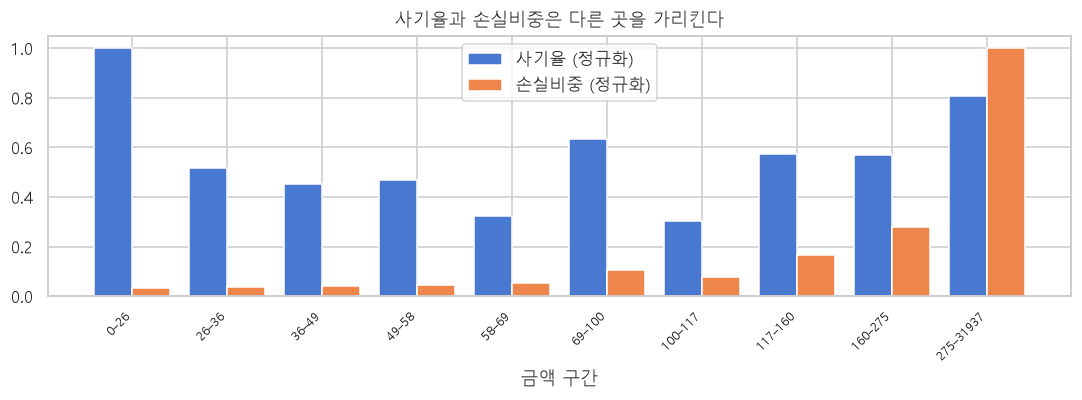

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(n_bins)
ax.bar(x - 0.2, bt["사기율"] / bt["사기율"].max(), 0.4, label="사기율 (정규화)")
ax.bar(x + 0.2, bt["손실비중"] / bt["손실비중"].max(), 0.4, label="손실비중 (정규화)")
ax.set_xticks(x); ax.set_xticklabels(bt["구간"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("금액 구간"); ax.legend()
ax.set_title("사기율과 손실비중은 다른 곳을 가리킨다")
plt.tight_layout(); plt.show()

## 4. 비용 파라미터 하에서의 차단 임계값

기획서 §1.4에서 유도한 대로, 임계값은 금액에 대해 **감소**한다:

$$p^* = \frac{m \cdot a + L}{a + c_{cb} + m \cdot a + L}$$

실제 금액 분포에 이 식을 적용하면 어떤 모양이 되는지 본다.

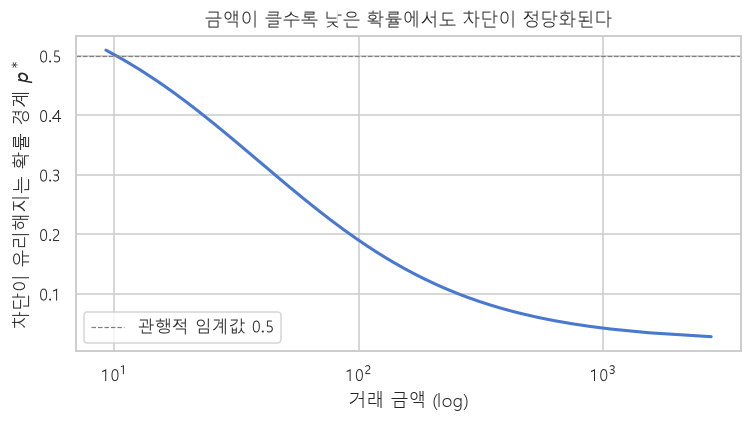

금액     25.95 → 임계값 0.3839
금액     68.77 → 임계값 0.2395
금액    275.29 → 임계값 0.0951
금액   1104.00 → 임계값 0.0404


In [20]:
from frauddetectionreport.costs import DEFAULT_PARAMS, block_threshold

grid = np.quantile(amt, np.linspace(0.01, 0.999, 200))
thr = block_threshold(grid, DEFAULT_PARAMS)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, thr, lw=2)
ax.set_xscale("log")
ax.set_xlabel("거래 금액 (log)"); ax.set_ylabel("차단이 유리해지는 확률 경계 $p^*$")
ax.set_title("금액이 클수록 낮은 확률에서도 차단이 정당화된다")
ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="관행적 임계값 0.5")
ax.legend()
plt.tight_layout(); plt.show()

for a in [np.quantile(amt, q) for q in (0.1, 0.5, 0.9, 0.99)]:
    print(f"금액 {a:9.2f} → 임계값 {block_threshold(np.array([a]), DEFAULT_PARAMS)[0]:.4f}")

> 관행적으로 쓰는 0.5는 이 곡선의 어디에도 대응하지 않는다.
> 이것이 P2(단일 임계값)와 P3/P4의 차이가 발생하는 지점이다.

## 5. 세그먼트별 사기율과 금액

06의 공정성 점검에서 확인할 세그먼트를 여기서 확정한다.
사기율이 높은 세그먼트는 정책상 과차단되기 쉬우므로,
**정상 고객까지 함께 막히지 않는지** 나중에 반드시 검증해야 한다.

In [21]:
for col in ["ProductCD", "DeviceType", "card4", "card6"]:
    if col not in train.columns:
        continue
    g = train.groupby(col, observed=True).agg(
        n=(TARGET, "size"), fraud_rate=(TARGET, "mean"),
        mean_amt=(AMOUNT_COL, "mean"),
    )
    g["loss_share"] = (train[train[TARGET] == 1]
                       .groupby(col, observed=True)[AMOUNT_COL].sum() / amt[y].sum())
    print(f"\n=== {col} ===")
    display(g[g.n >= 500].sort_values("fraud_rate", ascending=False)
            .style.format({"fraud_rate": "{:.3%}", "mean_amt": "{:.1f}", "loss_share": "{:.1%}"}))


=== ProductCD ===


,n,fraud_rate,mean_amt,loss_share
ProductCD,,,,
C,68519,11.687%,42.9,12.7%
S,11628,5.900%,60.3,1.4%
H,33024,4.766%,73.2,8.0%
R,37699,3.783%,168.3,11.3%
W,439670,2.040%,153.2,66.6%



=== DeviceType ===


,n,fraud_rate,mean_amt,loss_share
DeviceType,,,,
mobile,55645,10.166%,69.5,17.7%
desktop,85165,6.521%,92.6,14.6%



=== card4 ===


,n,fraud_rate,mean_amt,loss_share
card4,,,,
discover,6651,7.728%,265.8,5.9%
visa,384767,3.476%,133.2,64.8%
mastercard,189217,3.433%,132.4,27.7%
american express,8328,2.870%,173.1,1.4%



=== card6 ===


,n,fraud_rate,mean_amt,loss_share
card6,,,,
credit,148986,6.678%,190.0,53.7%
debit,439938,2.426%,116.3,46.1%


## 요약 — 정책 설계에 대한 예측

이 노트북에서 확인한 내용으로 06의 결과를 미리 예측해둔다.
예측이 맞았는지 대조하는 것이 보고서의 논리적 완결성을 만든다.

| 관찰 | 정책에 대한 함의 |
|---|---|
| 손실 집중도 (§2) | 집중되어 있다면 P4 > P3 의 개선폭이 클 것 |
| 사기율 ≠ 손실비중 (§3) | 건수 기준 지표만 보면 정책이 잘못된 구간에 집중 |
| 임계값 곡선 (§4) | 관행적 0.5는 근거가 없음 → P2의 한계 |
| 세그먼트 격차 (§5) | 06 공정성 점검 대상 확정 |

다음: `03_validation_design` — 검증 설계